In [1]:
%load_ext autoreload
%autoreload 2

import fractions
import numpy as np
import scipy.stats
import tqdm
import torch
from torch import tensor, Tensor
from typing import Iterable, Any

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import block_formats.quantisation as Q
import block_formats.analysis as A
import plot_utils

plot_utils.configure()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
UNDERLAY_ARGS = dict(zorder=0, ls=(0, (4, 1)), alpha=.5, lw=4, marker="x", ms=6)

def distribution_name(distribution: A.Distribution) -> str:
    if isinstance(distribution, A.StudentT):
        return f"t[$\\nu={distribution.df:.0f}$]"
    return type(distribution).__name__


Recommend (Ubuntu):
  sudo apt-get install cm-super dvipng fonts-cmu texlive-latex-extra


## Optimal formats

### `normal_crd_example_4bit`

remote: Updating references: 100% (1/1)           


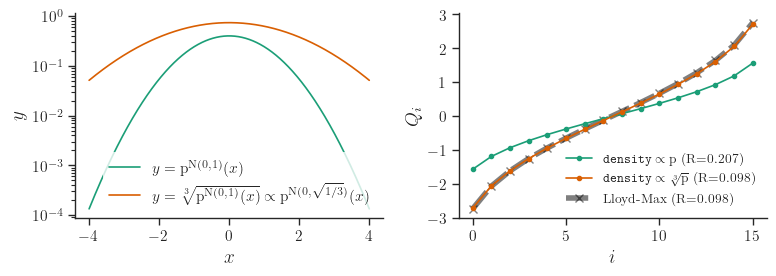

In [214]:
bits = 4
samples = 2**20

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3))

x = torch.linspace(-4, 4, 1001)
ax0.plot(x, scipy.stats.norm.pdf(x), label=r"$y = \mathrm{p}^{\mathrm{N}(0, 1)}(x)$")
ax0.plot(x, scipy.stats.norm.pdf(x)**(1/3), label=r"$y = \sqrt[3]{\mathrm{p}^{\mathrm{N}(0, 1)}(x)} \propto \mathrm{p}^{\mathrm{N}(0, \sqrt{1/3})}(x)$")
ax0.set_yscale("log")
ax0.set_xlabel("$x$")
ax0.set_ylabel(r"$y$")
ax0.legend(loc="lower right")

dist = A.Normal()
X = dist.sample(samples, seed=1, device=DEVICE)
for fmt in [
        Q.crd_normal(bits, power=1),
        Q.crd_normal(bits),
        Q.lut_lloyd_max(dist.sample(samples, seed=2, device=DEVICE), bits, 1e-4, init=("uniform_rms", 3)),
    ]:
    name = {
        "CRD{1}-N-RS": r"$\texttt{density} \propto \mathrm{p}$",
        "CRD-N-RS": r"$\texttt{density} \propto \sqrt[3]{\mathrm{p}}$",
        "LM": r"Lloyd-Max",
    }[fmt.name]
    rmse = Q.rmse_norm(X, fmt.quantise(X)).item()
    ax1.plot(fmt.values, label=f"{name} (R={rmse:.3f})",
             **(dict(UNDERLAY_ARGS, c="k") if fmt.name == "LM" else dict(marker="o")))
ax1.set_yticks(list(range(-3, 3+1)))
ax1.set_xlabel("$i$")
ax1.set_ylabel("$Q_i$")
ax1.legend(loc="lower right", fontsize=9.5)

plot_utils.tidy(fig)
plot_utils.save("normal_crd_example_4bit")

### `crd_curves_4bit`

remote: Updating references: 100% (1/1)           


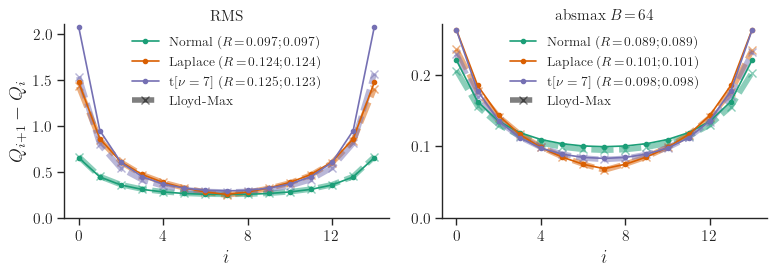

In [222]:
bits = 4
samples = 2**22
t_df = 7
block_size = 64

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3))

def lut_diff(fmt: Q.LUTFormat) -> Tensor:
    return tensor(fmt.values[1:]) - tensor(fmt.values[:-1])

dists = [
    A.Normal(scale=1),
    A.Laplace(scale=2**-0.5),
    A.StudentT(df=t_df, scale=((t_df - 2) / t_df) ** .5),
]
for dist, color in zip(dists, plot_utils.PALETTE):
    torch.manual_seed(1)
    X = dist.sample(samples, seed=1, device=DEVICE)
    X_LM = dist.sample(samples, seed=2, device=DEVICE)
    assert 0.95 <= A.rms(X).item() <= 1.05

    crd_fmt = dist.quantiser(bits)
    rmse = A.qrmse_norm(crd_fmt, X).item()
    lm_fmt = Q.lut_lloyd_max(X_LM, bits, 1e-4, init=("uniform_rms", 3))
    lm_rmse = A.qrmse_norm(lm_fmt, X).item()

    ax0.plot(lut_diff(crd_fmt), label=f"{distribution_name(dist)} ($R\\!=\\!{rmse:.3f} ; {lm_rmse:.3f}$)", c=color, marker="o")
    ax0.plot(lut_diff(lm_fmt), c=color, **UNDERLAY_ARGS)

    block_crd_fmt = dist.quantiser(bits, "absmax", block_size)
    block_rmse = A.qrmse_norm(Q.LinearScalingFormat(block_crd_fmt, Q.BFLOAT16, (block_size,), scaling="absmax"), X).item()
    block_lm_fmt = Q.lut_lloyd_max(A.block_normalise(X_LM, "absmax", block_size), bits, 1e-4, init="uniform_minmax")
    block_lm_rmse = A.qrmse_norm(Q.LinearScalingFormat(block_lm_fmt, Q.BFLOAT16, (block_size,), scaling="absmax"), X).item()

    ax1.plot(lut_diff(block_crd_fmt), label=f"{distribution_name(dist)} ($R\\!=\\!{block_rmse:.3f} ; {block_lm_rmse:.3f}$)", c=color, marker="o")
    ax1.plot(lut_diff(block_lm_fmt), c=color, **UNDERLAY_ARGS)

for ax in [ax0, ax1]:
    ax.set_xlabel("$i$")
    ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(4))
    h, _ = ax.get_legend_handles_labels()
    h.append(matplotlib.lines.Line2D([], [], color="k", **UNDERLAY_ARGS, label="Lloyd-Max"))
    ax.legend(handles=h, loc="upper center", fontsize=9.5)

ax0.set_ylim((0, 2.1))
ax1.set_ylim((0, 0.27))
ax1.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.1))

ax0.set_ylabel("$Q_{i+1} - Q_i$")
ax0.set_title("RMS", y=1, va="center")
ax1.set_title(f"absmax $B\\!=\\!{block_size}$", y=1, va="center")

plot_utils.tidy(fig)
plot_utils.save("crd_curves_4bit")

### `dist_absmax`

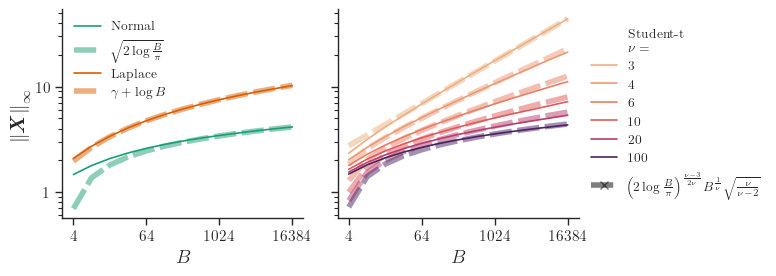

In [ ]:
samples = 2**22
B = tensor([2**n for n in range(2, 14+1)])

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3), sharey=True)

for color, dist in zip(plot_utils.PALETTE, [A.Normal(), A.Laplace()]):
    X = dist.sample(samples, seed=1, device=DEVICE)
    ax0.plot(B, [X.view(-1, Bi).abs().amax(-1).mean().item() for Bi in B], c=color, label=distribution_name(dist))
    if isinstance(dist, A.Normal):
        model = B.div(torch.pi).log().mul(2).sqrt()
        model_label = r"$\sqrt{2 \log \frac{B}{\pi}}$"
    if isinstance(dist, A.Laplace):
        model = B.log().add(0.57721566)
        model_label = r"$\gamma + \log B$"
    ax0.plot(B, model, **{**UNDERLAY_ARGS, "marker": None}, c=color, label=model_label)
ax0.legend(loc="upper left", fontsize=9.5)

t_dfs = tensor([3, 4, 6, 10, 20, 100])
for df, color in zip(t_dfs, plot_utils.SEQ_PALETTE(matplotlib.colors.LogNorm()(t_dfs))):
    X = A.StudentT(df.item()).sample(samples, seed=1, device=DEVICE)
    ax1.plot(B, [X.view(-1, Bi).abs().amax(-1).mean().item() for Bi in B], c=color, label=f"{df:.0f}")
    model = B.double().div(torch.pi).log().mul(2).pow((df-3)/2).mul(B).pow(1/df).mul((df/(df-2)).sqrt())
    ax1.plot(B, model, **{**UNDERLAY_ARGS, "marker": None}, c=color)
model_label = r"$\left(2 \log \frac{B}{\pi}\right)^{\frac{\nu-3}{2 \nu}}\! B^{\frac{1}{\nu}} \sqrt{\frac{\nu}{\nu - 2}}$"
h, _ = ax1.get_legend_handles_labels()
h.insert(0, matplotlib.lines.Line2D([], [], alpha=0, label="Student-t\n$\\nu=$"))
h.append(matplotlib.lines.Line2D([], [], color="k", **UNDERLAY_ARGS, label=model_label))
ax1.legend(handles=h, bbox_to_anchor=(1, 0.5), loc="center left", fontsize=9.5)

for ax in [ax0, ax1]:
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks([4, 64, 1024, 16384])
    ax.xaxis.set_major_formatter("{x:.0f}")
    ax.yaxis.set_major_formatter("{x:.0f}")
    ax.set_xlabel("$B$")
ax0.set_ylabel(r"$\norm{\bm{X}}{\infty}$")

plot_utils.tidy(fig)
plot_utils.save("dist_absmax")

### `normal_scaling_mode_example_3bit`

remote: Updating references: 100% (1/1)           


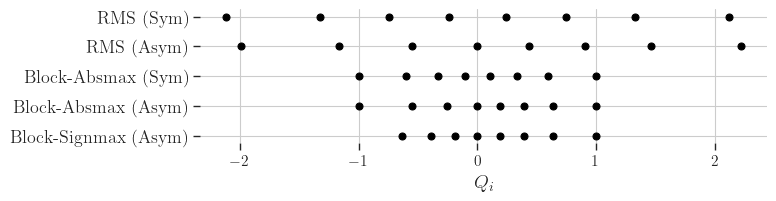

In [229]:
bits = 3
block_size = 64
dist = A.Normal()

plt_args = dict(color="k", s=25)
_, ax = plt.subplots(figsize=(8, 2.25))
y = torch.full((2**bits,), 0)
ax.scatter(dist.quantiser(bits, mode="symmetric").values, y, **plt_args, label="RMS (Sym)"); y -= 1
ax.scatter(dist.quantiser(bits, mode="asymmetric").values, y, **plt_args, label="RMS (Asym)"); y -= 1
ax.scatter(dist.quantiser(bits, scaling="absmax", block_size=block_size, mode="symmetric").values, y, **plt_args, label="Block-Absmax (Sym)"); y -= 1
ax.scatter(dist.quantiser(bits, scaling="absmax", block_size=block_size, mode="asymmetric").values, y, **plt_args, label="Block-Absmax (Asym)"); y -= 1
ax.scatter(dist.quantiser(bits, scaling="signmax", block_size=block_size, mode="asymmetric").values, y, **plt_args, label="Block-Signmax (Asym)"); y -= 1

ax.grid(True)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)
labels = ax.get_legend_handles_labels()[1]
ax.set_yticks(-torch.arange(len(labels)), labels, fontsize=13)
ax.set_ylim((-len(labels) + 1 - 0.25, 0.25))
ax.set_xlabel("$Q_i$")

plot_utils.tidy(ax.figure)
plot_utils.save("normal_scaling_mode_example_3bit")

### `block_scaled_distribution_example`

remote: Updating references: 100% (1/1)           


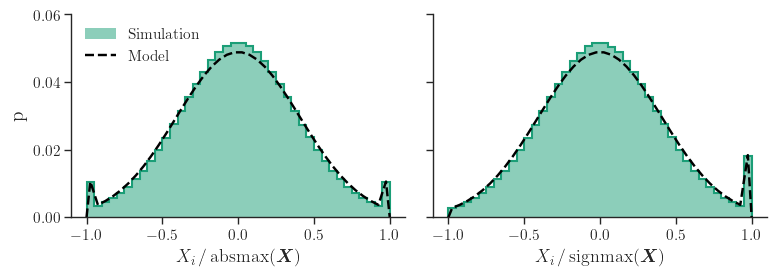

In [234]:
block_size = 64
X = A.Normal().sample(2**24, seed=1, device=DEVICE)
bins = torch.linspace(-1, 1, 41)

grid = plot_utils.grid(cols=["absmax", "signmax"], sharey=True)
for (scaling,), ax in grid:
    # Data
    Xn = A.block_normalise(X, scaling, block_size).cpu()
    W = torch.full_like(X, 1/X.nelement()).cpu()
    color = plot_utils.PALETTE[0]
    ax.hist(Xn, bins=bins, weights=W, color=color, histtype="bar", ec="none", alpha=.5, label="Simulation")
    ax.hist(Xn, bins=bins, weights=W, color=color, histtype="step", lw=1.5)

    # Model
    s = 1 / tensor(block_size).div(torch.pi).log().mul(2).sqrt()
    mids = (bins[:-1] + bins[1:]) / 2
    model = tensor(scipy.stats.truncnorm.pdf(mids, -1/s, 1/s, scale=s) * 2 / len(mids) * (block_size - 1) / block_size)
    if scaling == "absmax":
        model[0] += 0.5 / block_size
        model[-1] += 0.5 / block_size
    if scaling == "signmax":
        model[-1] += 1 / block_size
    ax.plot(torch.cat([tensor([-1]), mids, tensor([1])]), torch.cat([tensor([0]), model, tensor([0])]), color="k", lw=1.75, ls="--", label="Model")

    ax.set_ylim((0, 0.06))
    ax.set_xlabel(f"$X_i \\,/\\, \\mathrm{{{scaling}}}(\\bm{{X}})$", fontsize=13)

grid.axes[0, 0].yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.02))
grid.axes[0, 0].legend(loc="upper left")
grid.axes[0, 0].set_ylabel(r"$\mathrm{p}$")
plot_utils.tidy(grid.figure)
plot_utils.save("block_scaled_distribution_example")

## Block vs tensor formats on iid data

### `analysis_power_sweep_rms` & `analysis_power_sweep_absmax`

remote: Updating references: 100% (1/1)           
remote: Updating references: 100% (1/1)           


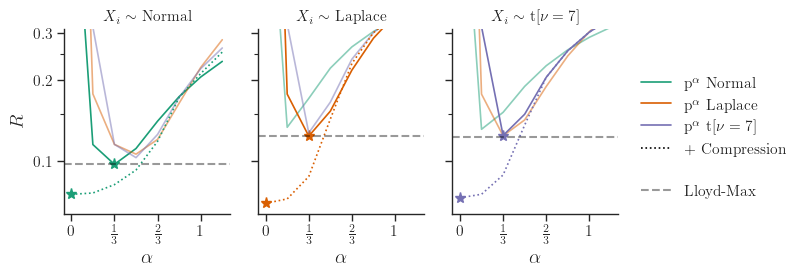

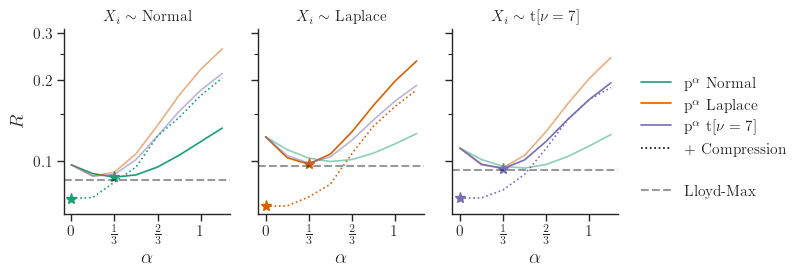

In [236]:
bits = 4
samples = 2**22
powers_except_zero = [1/6, 1/3, 1/2, 2/3, 5/6, 1, 7/6]
distributions = [A.Normal(), A.Laplace(), A.StudentT(7.)]

plt_args_lm = dict(ls="--", lw=1.5, alpha=.4, color="k")
plt_args_compressed = dict(ls=":")

for scaling, block_size in [("rms", None), ("absmax", 64)]:
    grid = plot_utils.grid(cols=distributions, sharey=True)
    for (dist,), ax in grid:
        X = A.block_normalise(dist.sample(samples, seed=1, device=DEVICE), scaling=scaling, block_size=block_size)
        X_train = A.block_normalise(dist.sample(samples, seed=2, device=DEVICE), scaling=scaling, block_size=block_size)

        for d, color in zip(distributions, plot_utils.PALETTE):
            powers = powers_except_zero.copy()
            if scaling == "rms" and type(d) != A.StudentT:
                powers.insert(0, 0.001)
            if scaling =="absmax":
                powers.insert(0, 0)
            rmse = [A.qrmse_norm(d.quantiser(bits, power=p, scaling=scaling, block_size=block_size), X).item() for p in powers]
            ax.plot(powers, rmse, color=color, alpha=1 if type(d) == type(dist) else 0.5)
            if type(d) == type(dist):
                idx = torch.argmin(tensor(rmse)).item()
                assert powers[idx] == 1/3
                ax.plot(powers[idx], rmse[idx], color=color, marker="*", ms=8)

        powers = [0] + powers_except_zero
        rmse = [A.qrmse_norm(d.find_compressed_quantiser(bits, X=X, X_train=X_train, power=p, scaling=scaling, block_size=block_size), X).item()
                for p in powers]
        color = plot_utils.PALETTE[distributions.index(dist)]
        ax.plot(powers, rmse, color=color, **plt_args_compressed)
        idx = torch.argmin(tensor(rmse)).item()
        assert powers[idx] == 0
        ax.plot(powers[idx], rmse[idx], color=color, marker="*", ms=8)

        lm_rmse = A.qrmse_norm(Q.lut_lloyd_max(X_train, bits, 1e-4, init=dict(rms=("uniform_rms", 3), absmax="uniform_minmax")[scaling]), X).item()
        ax.axhline(lm_rmse, **plt_args_lm)

        ax.set_xticks([0, 1/3, 2/3, 1])
        ax.xaxis.set_major_formatter(plot_utils.format_fraction())
        ax.set_xlabel(r"$\alpha$")
        ax.set_title(f"$X_i \\sim$ {distribution_name(dist)}")

    ax0 = grid.axes[0, 0]
    ax0.set_yscale("log")
    ax0.set_yticks([0.1, 0.2, 0.3])
    ax0.yaxis.set_minor_locator(matplotlib.ticker.FixedLocator([0.15, 0.25]))
    ax0.set_ylim((0.064, 0.31))
    ax0.yaxis.set_tick_params(which="minor", labelleft=False)
    ax0.yaxis.set_major_formatter("{x}")
    ax0.set_ylabel("qrmse_norm")

    plot_utils.set_figure_legend(grid.figure, handles=[
        matplotlib.lines.Line2D([], [], color=color, label=f"$\\mathrm{{p}}^{{\\alpha}}$ {distribution_name(dist)}")
        for dist, color in zip(distributions, plot_utils.PALETTE)
    ] + [
        matplotlib.lines.Line2D([], [], color="k", **plt_args_compressed, label=f"+ Compression"),
        matplotlib.patches.Patch(color="none"),
        matplotlib.lines.Line2D([], [], **plt_args_lm, label=f"Lloyd-Max"),
    ])

    plot_utils.tidy(grid.figure)
    plot_utils.save(f"analysis_power_sweep_{scaling}")

### `analysis_error_vs_bits`

remote: Updating references: 100% (1/1)           


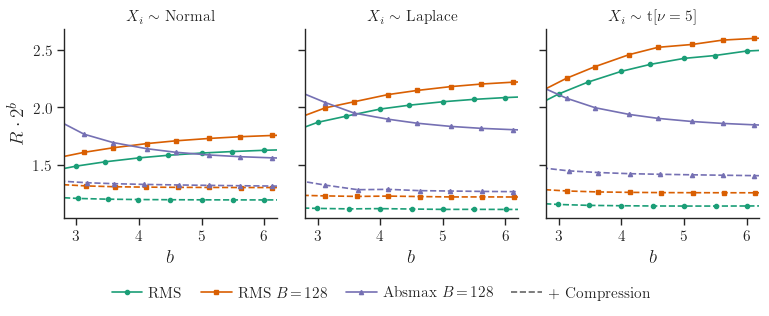

In [211]:
samples = 2**24
distributions = [A.Normal(), A.Laplace(), A.StudentT(df=5)]
b_elems = torch.arange(2.5, 6.5 + 0.1, 0.5).tolist()

block_size = 128
scaling_block_size = [
    ("rms", None, dict(label="RMS", marker="o", color=plot_utils.PALETTE[0])),
    ("rms", block_size, dict(label=f"RMS $B\\!=\\!{block_size}$", marker="s", color=plot_utils.PALETTE[1])),
    ("absmax", block_size, dict(label=f"Absmax $B\\!=\\!{block_size}$", marker="^", color=plot_utils.PALETTE[2])),
]

grid = plot_utils.grid(cols=distributions, sharey=True)
for (dist,), ax in grid:
    X = dist.sample(samples, seed=1, device=DEVICE)
    X_train = dist.sample(samples, seed=2, device=DEVICE)
    for scaling, block_size, args in scaling_block_size:
        quantiser_block_size = None if scaling == "rms" else block_size

        bs, ys = [], []
        for b_elem in b_elems:
            fmt = Q.LinearScalingFormat(
                    dist.quantiser(b_elem, scaling=scaling, block_size=quantiser_block_size),
                    Q.BFLOAT16, (block_size,), scaling=scaling,
            )
            b = fmt.count_bits(X.shape) / X.nelement()
            ys.append(A.qrmse_norm(fmt, X).item() * 2**b)
            bs.append(b)
        ax.plot(bs, ys, **args)

        bs, ys = [], []
        for b_elem in b_elems:
            efmt = dist.find_compressed_quantiser(
                        b_elem,
                        A.block_normalise(X, scaling=scaling, block_size=quantiser_block_size),
                        A.block_normalise(X_train, scaling=scaling, block_size=quantiser_block_size),
                        scaling=scaling,
                        block_size=quantiser_block_size,
                    )
            fmt = Q.LinearScalingCompressionFormat(
                    dist.find_compressed_quantiser(
                        b_elem,
                        A.block_normalise(X, scaling=scaling, block_size=quantiser_block_size),
                        A.block_normalise(X_train, scaling=scaling, block_size=quantiser_block_size),
                        scaling=scaling,
                        block_size=quantiser_block_size,
                    ),
                    Q.BFLOAT16, (block_size,), scaling=scaling,
            )
            b = fmt.count_bits_tensor(X) / X.nelement()
            ys.append(A.qrmse_norm(fmt, X).item() * 2**b)
            bs.append(b)
        ax.plot(bs, ys, **{k: v for k, v in args.items() if k != "label"}, ls="--")

    ax.set_xlim((3-0.2, 6+0.2))
    ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))

    ax.set_xlabel("bits")
    ax.set_title(f"$X_i \\sim$ {distribution_name(dist)}")

ax0 = grid.axes[0, 0]
ax0.set_ylabel(r"$R \cdot 2^b$")
ax0.yaxis.set_major_formatter("{x}")
plot_utils.set_figure_legend(grid.figure, handles=[
    matplotlib.lines.Line2D([], [], **a) for _, _, a in scaling_block_size
] + [
    matplotlib.lines.Line2D([], [], color="0.4", ls="--", label="+ Compression"),
],
    bbox_to_anchor=(0.0, 0.05, 1.0, 0), loc="upper center", ncols=4, columnspacing=1.25, handletextpad=0.4)

plot_utils.tidy(grid.figure)
plot_utils.save("analysis_error_vs_bits")

### `analysis_block_size`

remote: Updating references: 100% (1/1)           


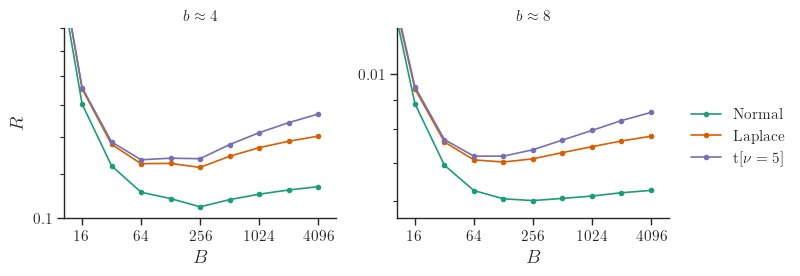

In [237]:
block_sizes = [2**logB for logB in range(3, 12+1)]
distributions = [A.Normal(), A.Laplace(), A.StudentT(df=5)]
grid = plot_utils.grid(cols=[4, 8])
for (b,), ax in grid:
    for dist in distributions:
        X = dist.sample(2**22, seed=1, device=DEVICE)
        rmse = []
        for block_size in block_sizes:
            fmt = Q.LinearScalingFormat(
                    dist.quantiser(b - 16 / block_size, scaling="absmax", block_size=block_size, mode="symmetric"),
                    Q.BFLOAT16, (block_size,), scaling="absmax",
            )
            assert b - 0.25 < fmt.count_bits(X.shape) / X.nelement() <= b
            rmse.append(A.qrmse_norm(fmt, X).item())
        ax.plot(block_sizes, rmse, label=distribution_name(dist), marker="o")

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter("{x}")
    ax.set_yticks([0.01, 0.03, 0.1, 0.3])
    ax.tick_params(axis="y", which="minor", labelleft=False)
    ax.set_ylim({4: (0.1, 0.22), 6: (0.023, 0.045), 8: (0.0056, 0.012)}[b])

    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter("{x:.0f}")
    ax.set_xticks([16, 64, 256, 1024, 4096])
    ax.set_xlim((16 * 0.65, 4096 / 0.65))

    ax.set_xlabel("block_size")
    ax.set_title(f"$b \\approx {b}$")

grid.axes[0, 0].set_ylabel("qrmse_norm")
plot_utils.share_legend(grid.figure)
plot_utils.tidy(grid.figure)
plot_utils.save("analysis_block_size")

---
# Graveyard

### Sweep

In [ ]:
samples = 2**22
# bs = torch.linspace(3, 6, 13).tolist()
bs = torch.linspace(3, 8, 21).tolist()
compressed_resolutions = torch.logspace(tensor(0.065).log(), tensor(0.8).log(), 13, base=torch.e).tolist()
Bs = [2**logB for logB in range(3, 12+1)]
distributions = [A.Normal(), A.Laplace(), A.StudentT(df=5)]

def sweep() -> Iterable[dict[str, Any]]:
    for dist in distributions:
        X = dist.sample(samples, seed=1, device=DEVICE)
        X_train = dist.sample(samples, seed=2, device=DEVICE)
        for b in tqdm.tqdm(bs, desc=type(dist).__name__):
            fmts = []

            # Tensor & Block
            for edist in distributions:
                fmts.append((Q.LinearScalingFormat(edist.quantiser(b), Q.BFLOAT16, (None,), scaling="rms"),
                             dict(scaling="rms", edist_name=distribution_name(edist))))
                for B in Bs:
                    fmts.append((Q.LinearScalingFormat(edist.quantiser(b - 16 / B, scaling="absmax", block_size=B, mode="symmetric"), Q.BFLOAT16, (B,), scaling="absmax"),
                                 dict(scaling="absmax", block_size=B, edist_name=distribution_name(edist))))

            # Lloyd-Max
            if b <= 5.25:  # speed hack
                fmts.append((Q.LinearScalingFormat(Q.lut_lloyd_max(A.rms_normalise(X_train), b, 1e-4, init=("uniform_rms", 3)), Q.BFLOAT16, (None,), scaling="rms"),
                            dict(scaling="rms")))
                for edist in distributions:
                    fmts.append((Q.LinearScalingFormat(Q.lut_lloyd_max(A.block_normalise(X_train, "absmax", B), b - 16 / B, 1e-4, init="uniform_minmax"), Q.BFLOAT16, (B,), scaling="absmax"),
                                dict(scaling="absmax", block_size=B)))

            # Compressed
            for resolution in compressed_resolutions:
                fmts.append(((Q.LinearScalingCompressionFormat(Q.UniformAndCompressionFormat.train(A.rms_normalise(X_train), resolution), Q.BFLOAT16, (None,), scaling="rms")),
                              dict(scaling="rms", resolution=resolution)))

            for fmt, detail in fmts:
                if isinstance(fmt, Q.LinearScalingCompressionFormat):
                    efmt = "CGRID"
                    bits = fmt.count_bits_tensor(X) / X.nelement()
                elif isinstance(fmt, Q.LinearScalingFormat):
                    efmt = fmt.element_format.name
                    bits = fmt.count_bits(X.shape) / X.nelement()
                yield dict(
                    dist=distribution_name(dist),
                    dist_type=type(dist).__name__,
                    fmt=str(fmt),
                    efmt=efmt,
                    **detail,
                    bits=bits,
                    qrmse_norm=A.qrmse_norm(fmt, X).item(),
                )

df = pd.DataFrame.from_records(list(sweep()))
display(df)

Normal:   0%|          | 0/21 [00:00<?, ?it/s]

StudentT: 100%|██████████| 21/21 [00:22<00:00,  1.05s/it]


,dist,dist_type,fmt,efmt,scaling,edist_name,bits,qrmse_norm,block_size,resolution
0,Normal,Normal,LUT3[CRD-N-RS]{*:BFLOAT16:rms},CRD-N-RS,rms,Normal,3.000004,0.185960,NaN,NaN
1,Normal,Normal,LUT1[CRD-N-AS]{8:BFLOAT16:absmax},CRD-N-AS,absmax,Normal,3.000000,1.206703,8.0,NaN
2,Normal,Normal,LUT2[CRD-N-AS]{16:BFLOAT16:absmax},CRD-N-AS,absmax,Normal,3.000000,0.380763,16.0,NaN
3,Normal,Normal,LUT3[CRD-N-AS]{32:BFLOAT16:absmax},CRD-N-AS,absmax,Normal,2.821928,0.314486,32.0,NaN
4,Normal,Normal,LUT3[CRD-N-AS]{64:BFLOAT16:absmax},CRD-N-AS,absmax,Normal,2.834963,0.269711,64.0,NaN
...,...,...,...,...,...,...,...,...,...,...
3013,t[$\nu=5$],StudentT,CGRID[0.3]{*:BFLOAT16:rms},CGRID,rms,NaN,3.944024,0.099837,NaN,0.346496
3014,t[$\nu=5$],StudentT,CGRID[0.4]{*:BFLOAT16:rms},CGRID,rms,NaN,3.644614,0.123074,NaN,0.427116
3015,t[$\nu=5$],StudentT,CGRID[0.5]{*:BFLOAT16:rms},CGRID,rms,NaN,3.346014,0.151780,NaN,0.526495
3016,t[$\nu=5$],StudentT,CGRID[0.6]{*:BFLOAT16:rms},CGRID,rms,NaN,3.049872,0.187134,NaN,0.648996


### `analysis_error_vs_bits` (v2)

remote: Updating references: 100% (1/1)           


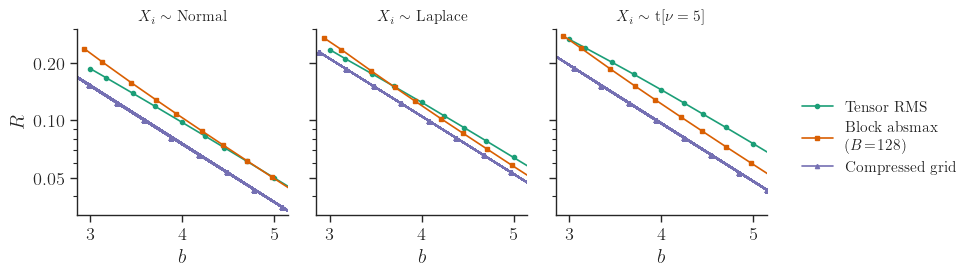

In [ ]:
block_size = 128
plt_args = dict(
    rms=dict(color=plot_utils.PALETTE[0], marker="o", label=f"Tensor RMS"),
    absmax=dict(color=plot_utils.PALETTE[1], marker="s", label=f"Block absmax\n($B\\!=\\!{block_size}$)"),
    cgrid=dict(color=plot_utils.PALETTE[2], marker="^", label=f"Compressed grid"),
    # lm=dict(color="k", **UNDERLAY_ARGS, label=f"Lloyd-Max"),
)

g = plot_utils.grid_df(df, col="dist", sharey=True)
for (dist,), d, ax in g:
    dd = d[(d["dist"] == d["edist_name"]) & (d["scaling"] == "rms")]
    dd.plot(y="qrmse_norm", ylabel="qrmse_norm", x="bits", **plt_args["rms"], ax=ax)

    dd = d[(d["dist"] == d["edist_name"]) & (d["scaling"] == "absmax") & (d["block_size"] == block_size)]
    dd.plot(y="qrmse_norm", ylabel="qrmse_norm", x="bits", **plt_args["absmax"], ax=ax)

    dd = d[(d["efmt"] == "CGRID")]
    dd.plot(y="qrmse_norm", ylabel="qrmse_norm", x="bits", **plt_args["cgrid"], ax=ax)

    # dd = d[(d["efmt"] == "LM") & (d["scaling"] == "rms")]  # TODO
    # dd.plot(y="qrmse_norm", ylabel="qrmse_norm", x="bits", **plt_args["lm"], ax=ax)

    ax.set_yscale("log")
    ax.set_ylim((0.032, 0.3))
    ax.yaxis.set_major_formatter("{x:.2f}")
    ax.yaxis.set_ticks([0.05, 0.1, 0.2])
    ax.tick_params(axis="y", which="minor", labelleft=False)
    ax.set_xlim((3-0.15, 5+0.15))
    ax.set_xticks(list(range(3, 5+1)))

    ax.set_title(f"$X_i \\sim$ {dist}")
    ax.legend_.remove()

g.figure.legend(handles=[
    matplotlib.lines.Line2D([], [], **a) for a in plt_args.values()
], loc="center left", bbox_to_anchor=(1, 0.5))

plot_utils.tidy(g.figure)
# plot_utils.save("analysis_error_vs_bits")

### `analysis_error_vs_bits` (v1)

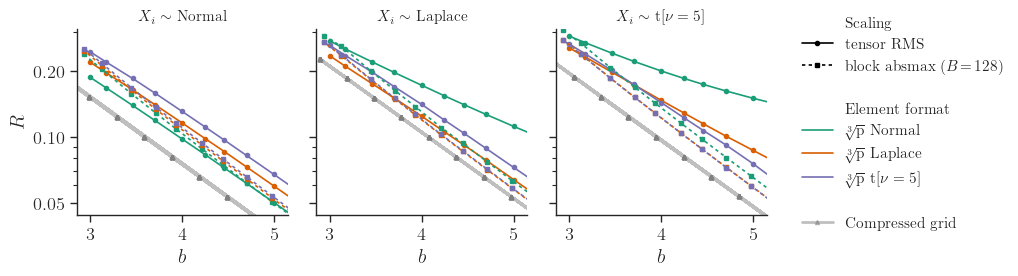

In [ ]:
plt_args = dict(
    rms=dict(marker="o"),
    absmax=dict(ls=(0, (2, 2)), marker="s"),
    compressed=dict(color="gray", alpha=.5, lw=2, marker="^"),
)
block_size = 128
edist_to_color = dict(zip(df["edist_name"].dropna().unique(), plot_utils.PALETTE))

g = plot_utils.grid(df[(df["efmt"] != "LM")], col="dist", sharey=True)
for (dist,), d, ax in g:
    for edist_name, dd in d[(d["scaling"] == "rms") & (d["efmt"] != "CGRID")].groupby("edist_name", sort=False):
        dd.plot(y="qrmse_norm", ylabel="qrmse_norm", x="bits", color=edist_to_color[edist_name], **plt_args["rms"], ax=ax)

    dash_offset = 0
    for edist_name, dd in d[(d["scaling"] == "absmax") & (d["block_size"] == block_size)].groupby("edist_name", sort=False):
        dd.plot(y="qrmse_norm", ylabel="qrmse_norm", x="bits", color=edist_to_color[edist_name],
                **{**plt_args["absmax"], "ls": (dash_offset, plt_args["absmax"]["ls"][1])}, ax=ax)
        dash_offset += 1.25

    d[(d["efmt"]) == "CGRID"].plot(y="qrmse_norm", ylabel="qrmse_norm", x="bits", **plt_args["compressed"], ax=ax)

    ax.set_yscale("log")
    ax.set_ylim((0.044, 0.31))
    ax.yaxis.set_major_formatter("{x:.2f}")
    ax.yaxis.set_ticks([0.05, 0.1, 0.2])
    ax.tick_params(axis="y", which="minor", labelleft=False)
    ax.set_xlim((3-0.15, 5+0.15))
    ax.set_xticks(list(range(3, 5+1)))

    ax.set_title(f"$X_i \\sim$ {dist}")
    ax.legend_.remove()

h = []
h.append(matplotlib.patches.Patch(facecolor="none", label="Scaling"))
h.append(matplotlib.lines.Line2D([], [], color="k", **plt_args["rms"], label=f"tensor RMS"))
h.append(matplotlib.lines.Line2D([], [], color="k", **plt_args["absmax"], label=f"block absmax ($B\\!=\\!{block_size}$)"))
h.append(matplotlib.patches.Patch(facecolor="none"))
h.append(matplotlib.patches.Patch(facecolor="none", label="Element format"))
for edist_name, color in edist_to_color.items():
    h.append(matplotlib.lines.Line2D([], [], color=color, label=f"{plot_utils.CRD_LABEL} {edist_name}"))
h.append(matplotlib.patches.Patch(facecolor="none"))
h.append(matplotlib.lines.Line2D([], [], **plt_args["compressed"], label=f"Compressed grid"))
g.figure.legend(handles=h, loc="upper left", bbox_to_anchor=(1, 0.95))

plot_utils.tidy(g.figure)
# plot_utils.save("analysis_error_vs_bits")

### `analysis_block_size_4bit`

remote: Updating references: 100% (1/1)           


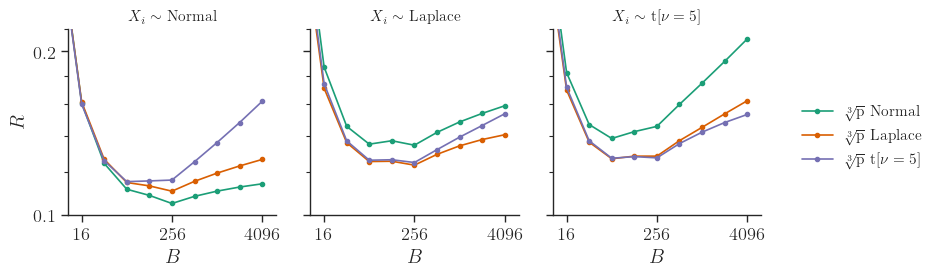

In [ ]:
b = 4

g = plot_utils.grid(df[(df["scaling"] != "rms") & (b - 0.25 < df["bits"]) & (df["bits"] <= b)], col="dist", sharey=True)
for (dist,), d, ax in g:
    for efmt, dd in d.groupby("efmt", sort=False):
        dd.sort_values("block_size").plot(y="qrmse_norm", ylabel="qrmse_norm", x="block_size", label=efmt, marker="o", ax=ax)

    ax.set_yscale("log")
    ax.set_ylim((0.1, 0.22))
    ax.set_yticks([0.1, 0.2])
    ax.yaxis.set_major_formatter("{x:.1f}")
    ax.tick_params(axis="y", which="minor", labelleft=False)
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter("{x:.0f}")
    ax.set_xticks([16, 256, 4096])
    ax.set_xlim((16 * 0.65, 4096 / 0.65))

    ax.set_title(f"$X_i \\sim$ {dist}")

plot_utils.share_legend(g.figure)
plot_utils.tidy(g.figure)
# plot_utils.save("analysis_block_size_4bit")